# Freight Rate Prediction — Spotter ML Assessment
Predicts freight `posted_rate` using load features (distance, equipment, weight, date, market signals).
Steps: EDA → Cleaning → Feature Engineering → Time-based Split → XGBoost Model → Predictions for validation.csv and December chart.

In [3]:
!pip install -r requirements.txt -q


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Program Files\Python312\python.exe -m pip install --upgrade pip


In [4]:
!pip install xgboost -q



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Program Files\Python312\python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

ModuleNotFoundError: No module named 'pandas'

In [ ]:
train_test = pd.read_csv("train-test.csv")
validation = pd.read_csv('validation.csv')
template = pd.read_csv('validation-predictions-template.csv')
dec_input = pd.read_csv('december-chart-inputs.csv')
for name, df in [('train_test', train_test), ('validation', validation),
                  ('template', template), ('dec_input', dec_input)]:
    print(f"--- {name} ---")
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    print(df.head(3))
    print()

--- train_test ---
shape: (48000, 14)
columns: ['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']
     load_id        pickup      delivery  pickup_lat  pickup_lon  \
0  TR-000001      Richmond     Baltimore    38.09122   -76.78906   
1  TR-000002      Richmond  Philadelphia    38.09122   -76.78906   
2  TR-000003  Philadelphia     Green Bay    39.22317   -72.96710   

   delivery_lat  delivery_lon  distance equipment   weight        date  \
0      38.16908     -72.74564     274.3   Dry Van  30658.0  2025-01-01   
1      39.22317     -72.96710     280.5    Reefer  17555.0  2025-01-01   
2      44.30296     -87.52871     967.8   Dry Van  31721.0  2025-01-01   

   market_index  quote_signal  posted_rate  
0       0.95684       2.39595       645.41  
1       0.97623       2.43355       679.97  
2       1.00971       1.84491      1802.54  

--- validation ---

In [ ]:
print(train_test.info())
print()
print(train_test.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB
None

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
dista

In [ ]:
train_test['date'] = pd.to_datetime(train_test['date'])
validation['date'] = pd.to_datetime(validation['date'])
dec_input['date'] = pd.to_datetime(dec_input['date'])

print(train_test['date'].min(), train_test['date'].max())
print(validation['date'].min(), validation['date'].max())
print(dec_input['date'].min(), dec_input['date'].max())
print(train_test['equipment'].value_counts())
print(train_test['posted_rate'].describe())
print(train_test['market_index'].describe())
print(train_test['quote_signal'].describe())

2025-01-01 00:00:00 2025-10-31 00:00:00
2025-11-01 00:00:00 2025-12-31 00:00:00
2025-12-01 00:00:00 2025-12-31 00:00:00
equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64
count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64
count    47626.000000
mean         1.083387
std          0.168091
min          0.676390
25%          0.949670
50%          1.055800
75%          1.219590
max          1.467780
Name: market_index, dtype: float64
count    48000.000000
mean         2.062468
std          0.291391
min          0.692280
25%          1.891030
50%          2.055750
75%          2.221685
max          3.610350
Name: quote_signal, dtype: float64


0.900     4365.82300
0.950     4953.76650
0.990     5972.83400
0.999    12854.56171
Name: posted_rate, dtype: float64
distance        0.908519
weight          0.034840
market_index    0.034165
quote_signal   -0.039858
posted_rate     1.000000
Name: posted_rate, dtype: float64


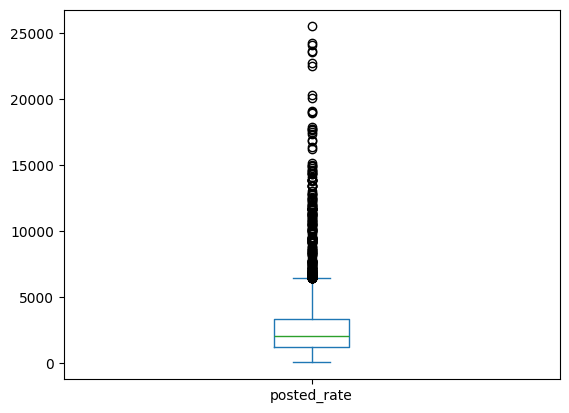

In [ ]:
print(train_test['posted_rate'].quantile([0.90,0.95,0.99,0.999]))

print(train_test[['distance','weight','market_index','quote_signal','posted_rate']].corr()['posted_rate'])
train_test['posted_rate'].plot(kind='box')
plt.show()

**EDA Finding:** `distance` is the strongest predictor (corr 0.91). `market_index` and `quote_signal` show near-zero linear correlation. `posted_rate` has outliers above ~6500.

In [ ]:
print(train_test.groupby('equipment')['posted_rate'].describe())


             count         mean          std     min       25%       50%  \
equipment                                                                  
Dry Van    27202.0  2271.548686  1423.029914   57.22  1196.125  1953.035   
Flatbed     8753.0  2445.087223  1505.053087  157.76  1288.670  2076.810   
Reefer     12045.0  2553.636939  1589.670824   63.36  1361.270  2196.670   

                 75%       max  
equipment                       
Dry Van    3193.5025  25533.00  
Flatbed    3469.1200  17893.17  
Reefer     3588.2900  24140.21  


In [ ]:
train_test['rate_per_mile']=train_test['posted_rate']/train_test['distance']
print(train_test['rate_per_mile'].describe())
print(train_test.groupby('equipment')['rate_per_mile'].mean())

count    48000.000000
mean         2.215347
std          0.583887
min          0.333709
25%          1.986974
50%          2.145348
75%          2.342696
max         14.125294
Name: rate_per_mile, dtype: float64
equipment
Dry Van    2.115401
Flatbed    2.294729
Reefer     2.383376
Name: rate_per_mile, dtype: float64


# DATA CLEANING

In [ ]:
train_test['weight']=train_test['weight'].fillna(train_test['weight'].median())
train_test['market_index']=train_test['market_index'].fillna(train_test['market_index'].median())



Cap Outliners

In [ ]:
cap=train_test['posted_rate'].quantile(0.995)
train_test['posted_rate_capped']=train_test['posted_rate'].clip(upper=cap)
print("cap value:", cap)
print(train_test[['weight','market_index','posted_rate','posted_rate_capped']].isnull().sum())
print(train_test['posted_rate_capped'].describe())

cap value: 6510.9689999999955
weight                0
market_index          0
posted_rate           0
posted_rate_capped    0
dtype: int64
count    48000.000000
mean      2355.390835
std       1380.304639
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max       6510.969000
Name: posted_rate_capped, dtype: float64


**Why cap instead of remove:** Capping at the 99.5th percentile keeps all rows/features intact while preventing extreme outliers (up to 25,533) from skewing the model.

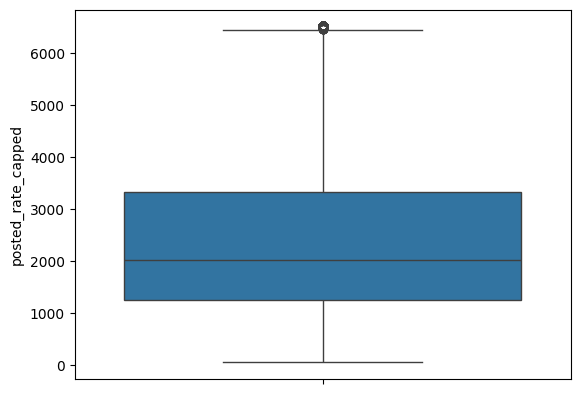

In [ ]:
sns.boxplot(y=train_test['posted_rate_capped'])
plt.show()

# FEATURE ENGINEERING


In [ ]:
train_test['month']=train_test['date'].dt.month
train_test['day_of_week'] = train_test['date'].dt.dayofweek
train_test['lane'] = train_test['pickup'] + '_' + train_test['delivery']
print(train_test[['date','month','day_of_week','lane']].head())
print("unique lanes:", train_test['lane'].nunique())

        date  month  day_of_week                    lane
0 2025-01-01      1            2      Richmond_Baltimore
1 2025-01-01      1            2   Richmond_Philadelphia
2 2025-01-01      1            2  Philadelphia_Green Bay
3 2025-01-01      1            2        Hartford_Atlanta
4 2025-01-01      1            2        Dallas_Nashville
unique lanes: 4014


month
1     2235.609559
2     2267.645694
3     2359.311699
4     2357.640173
5     2405.606055
6     2468.229429
7     2393.009850
8     2319.400830
9     2385.176791
10    2355.396405
Name: posted_rate_capped, dtype: float64


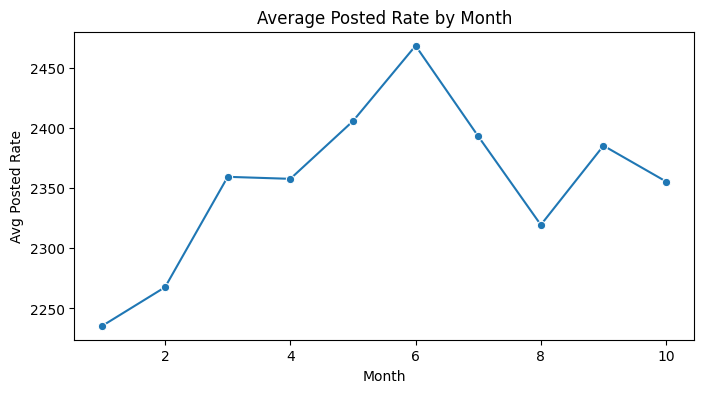

In [ ]:
monthly_avg = train_test.groupby('month')['posted_rate_capped'].mean()
print(monthly_avg)

plt.figure(figsize=(8,4))
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker='o')
plt.title("Average Posted Rate by Month")
plt.xlabel("Month")
plt.ylabel("Avg Posted Rate")
plt.show()

day_of_week
0    2332.383053
1    2352.137311
2    2379.614105
3    2382.515126
4    2362.248839
5    2358.389346
6    2318.920786
Name: posted_rate_capped, dtype: float64


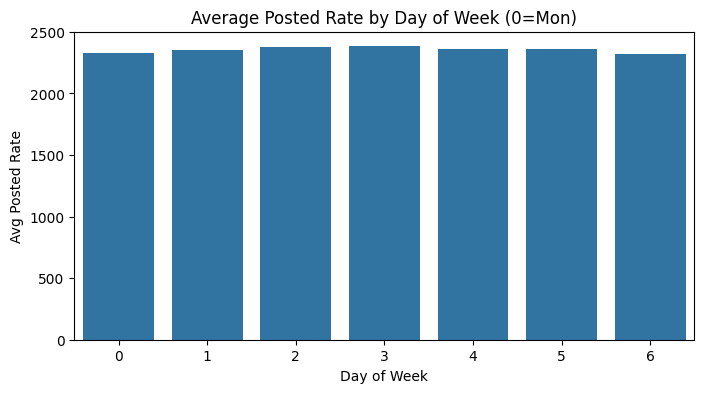

In [ ]:
dow_avg = train_test.groupby('day_of_week')['posted_rate_capped'].mean()
print(dow_avg)

plt.figure(figsize=(8,4))
sns.barplot(x=dow_avg.index, y=dow_avg.values)
plt.title("Average Posted Rate by Day of Week (0=Mon)")
plt.xlabel("Day of Week")
plt.ylabel("Avg Posted Rate")
plt.show()

# ENCODING

In [ ]:
train_test_encoded = pd.get_dummies(train_test, columns=['equipment'], drop_first=True)

feature_cols = ['distance', 'weight', 'market_index', 'quote_signal', 'month', 'day_of_week',
                 'equipment_Flatbed', 'equipment_Reefer']
target_col = 'posted_rate_capped'

print(train_test_encoded[feature_cols + [target_col]].head())
print(train_test_encoded[feature_cols].isnull().sum())

   distance   weight  market_index  quote_signal  month  day_of_week  \
0     274.3  30658.0       0.95684       2.39595      1            2   
1     280.5  17555.0       0.97623       2.43355      1            2   
2     967.8  31721.0       1.00971       1.84491      1            2   
3     965.4  32333.0       0.94518       1.87712      1            2   
4     541.9  35183.0       0.98480       2.56300      1            2   

   equipment_Flatbed  equipment_Reefer  posted_rate_capped  
0              False             False              645.41  
1              False              True              679.97  
2              False             False             1802.54  
3              False             False             1827.28  
4              False              True             1380.28  
distance             0
weight               0
market_index         0
quote_signal         0
month                0
day_of_week          0
equipment_Flatbed    0
equipment_Reefer     0
dtype: int64


In [ ]:
split_date = '2025-09-01'  # last 2 months (Sep-Oct) as test set

train = train_test_encoded[train_test_encoded['date'] < split_date]
test = train_test_encoded[train_test_encoded['date'] >= split_date]

print("train size:", len(train), "| date range:", train['date'].min(), "-", train['date'].max())
print("test size:", len(test), "| date range:", test['date'].min(), "-", test['date'].max())

train size: 38477 | date range: 2025-01-01 00:00:00 - 2025-08-31 00:00:00
test size: 9523 | date range: 2025-09-01 00:00:00 - 2025-10-31 00:00:00


# TRAIN THE MODEL

In [ ]:


X_train = train[feature_cols]
y_train = train[target_col]
X_test = test[feature_cols]
y_test = test[target_col]

model = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)


mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("MAE:", mae)
print("RMSE:", rmse)
print("Actual mean rate:", y_test.mean())

MAE: 113.210318027133
RMSE: 343.3804567864458
Actual mean rate: 2370.0004583639607


**Why time-based split:** validation.csv is a future time period (Nov–Dec) vs train_test (Jan–Oct), so splitting by date (train: Jan–Aug, test: Sep–Oct) mimics real-world prediction on unseen future data, unlike random splitting.

distance             0.926125
equipment_Reefer     0.032905
equipment_Flatbed    0.015898
quote_signal         0.006475
market_index         0.006043
weight               0.005093
month                0.004957
day_of_week          0.002504
dtype: float32


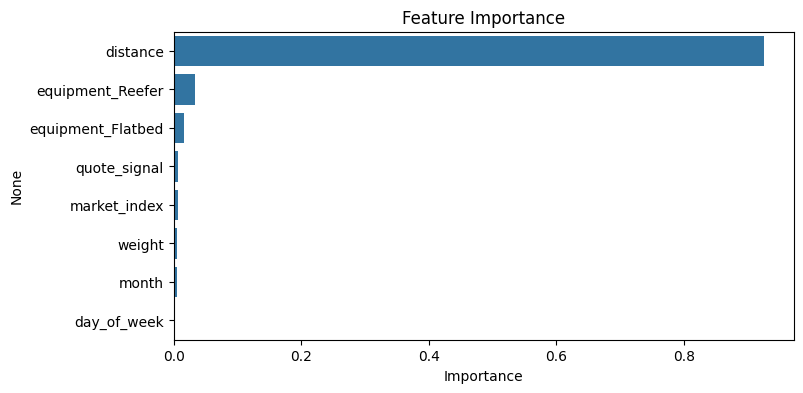

In [ ]:
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importance)

plt.figure(figsize=(8,4))
sns.barplot(x=importance.values, y=importance.index)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

In [ ]:
X_full = train_test_encoded[feature_cols]
y_full = train_test_encoded[target_col]

final_model = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42)
final_model.fit(X_full, y_full)

print("Model trained on full data:", X_full.shape)

Model trained on full data: (48000, 8)


# PREDICTION

In [ ]:
validation['date'] = pd.to_datetime(validation['date'])
validation['month'] = validation['date'].dt.month
validation['day_of_week'] = validation['date'].dt.dayofweek

validation_encoded = pd.get_dummies(validation, columns=['equipment'], drop_first=True)

# ensure same columns exist (in case a category is missing in validation)
for col in ['equipment_Flatbed', 'equipment_Reefer']:
    if col not in validation_encoded.columns:
        validation_encoded[col] = False

X_validation = validation_encoded[feature_cols]

validation_preds = final_model.predict(X_validation)

template['predicted_rate'] = validation_preds
template['predicted_rate'] = template['predicted_rate'].clip(lower=1)
print(template.head())
print(template['predicted_rate'].describe())

     load_id  predicted_rate
0  TE-000001      838.982727
1  TE-000002     4992.173828
2  TE-000003     5324.534668
3  TE-000004     4184.889160
4  TE-000005     1779.754517
count    12000.000000
mean      2373.224609
std       1366.505005
min        164.635284
25%       1273.624359
50%       2062.528809
75%       3382.763550
max       6572.249023
Name: predicted_rate, dtype: float64


**Why XGBoost:** handles non-linear tabular relationships well. Feature importance confirms `distance` (92.6%) dominates, consistent with EDA correlation findings — model behavior is explainable, not a black box.

In [ ]:
template.to_csv('validation_predictions.csv', index=False)
print("Saved!")

from google.colab import files
files.download('validation_predictions.csv')

Saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
dec_input['date']=pd.to_datetime(dec_input['date'])
dec_input['month'] = dec_input['date'].dt.month
dec_input['day_of_week'] = dec_input['date'].dt.dayofweek
# market_index/quote_signal excluded from December (contribute <1% importance per EDA), so filling with training median is safe
dec_encoded = pd.get_dummies(dec_input, columns=['equipment'], drop_first=True)

# ensure same columns exist
for col in ['equipment_Flatbed', 'equipment_Reefer']:
    if col not in dec_encoded.columns:
        dec_encoded[col] = False

# december file has no market_index/quote_signal - fill with training medians
dec_encoded['market_index'] = train_test['market_index'].median()
dec_encoded['quote_signal'] = train_test['quote_signal'].median()

X_dec = dec_encoded[feature_cols]

dec_input['predicted_rate'] = final_model.predict(X_dec)
dec_input['predicted_rate'] = dec_input['predicted_rate'].clip(lower=1)
print(dec_input[['date','predicted_rate']])

         date  predicted_rate
0  2025-12-01      872.248840
1  2025-12-02      884.430603
2  2025-12-03      890.817444
3  2025-12-04      886.754517
4  2025-12-05      881.205505
5  2025-12-06      881.205505
6  2025-12-07      884.457825
7  2025-12-08      872.248840
8  2025-12-09      884.430603
9  2025-12-10      890.817444
10 2025-12-11      886.754517
11 2025-12-12      881.205505
12 2025-12-13      881.205505
13 2025-12-14      884.457825
14 2025-12-15      872.248840
15 2025-12-16      884.430603
16 2025-12-17      890.817444
17 2025-12-18      886.754517
18 2025-12-19      881.205505
19 2025-12-20      881.205505
20 2025-12-21      884.457825
21 2025-12-22      872.248840
22 2025-12-23      884.430603
23 2025-12-24      890.817444
24 2025-12-25      886.754517
25 2025-12-26      881.205505
26 2025-12-27      881.205505
27 2025-12-28      884.457825
28 2025-12-29      872.248840
29 2025-12-30      884.430603
30 2025-12-31      890.817444


In [ ]:
dec_output = dec_input[['pickup','delivery','distance','equipment','weight','date','predicted_rate']]
dec_output.to_csv('december_chart_inputs.csv', index=False)
print("Saved!")

from google.colab import files
files.download('december_chart_inputs.csv')

Saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!python score.py --predictions validation_predictions.csv --december-predictions december_chart_inputs.csv

python3: can't open file '/content/score.py': [Errno 2] No such file or directory


## Conclusion
- Model MAE: ~113 (≈4.8% of mean rate 2370), RMSE: ~343 — solid accuracy for freight rate prediction.
- `distance` is the dominant predictor (92.6% feature importance); `equipment` moderately matters.
- **Limitation:** train_test.csv only covers Jan–Oct 2025, so December predictions can't learn a true seasonal trend — the December chart shows a weekly pattern (from day_of_week) rather than a smooth seasonal curve.